Importing Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import f_oneway, chi2_contingency, pearsonr


In [3]:
from google.colab import files

uploaded = files.upload()

Saving HRDataset_v14.csv to HRDataset_v14.csv


Data Load

In [4]:
df = pd.read_csv('HRDataset_v14.csv')

Initial Data Inspection

In [5]:
print(f"Shape: {df.shape}")
df.info()

Shape: (311, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State             

In [6]:
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


In [7]:
pd.DataFrame({
    "missing":df.isnull().sum(),
    "percentage":df.isnull().sum()*100/len(df)
})

,missing,percentage
Employee_Name,0,0.000000
EmpID,0,0.000000
MarriedID,0,0.000000
MaritalStatusID,0,0.000000
GenderID,0,0.000000
EmpStatusID,0,0.000000
DeptID,0,0.000000
PerfScoreID,0,0.000000
FromDiversityJobFairID,0,0.000000
Salary,0,0.000000


In [8]:
df.duplicated().sum()

np.int64(0)

Basic Data Cleaning (Fixing Data Type and Dropping Irrelevant Columns)

In [9]:
drop_cols = [
    "Employee_Name",
    "EmpID",
    "MarriedID",
    "MaritalStatusID",
    "GenderID",
    "EmpStatusID",
    "DeptID",
    "PerfScoreID",
    "PositionID",
    "Zip",
    "ManagerID",
    "FromDiversityJobFairID",
    "ManagerName",
    "TermReason"

]

df = df.drop(columns=drop_cols)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Salary                      311 non-null    int64  
 1   Termd                       311 non-null    int64  
 2   Position                    311 non-null    object 
 3   State                       311 non-null    object 
 4   DOB                         311 non-null    object 
 5   Sex                         311 non-null    object 
 6   MaritalDesc                 311 non-null    object 
 7   CitizenDesc                 311 non-null    object 
 8   HispanicLatino              311 non-null    object 
 9   RaceDesc                    311 non-null    object 
 10  DateofHire                  311 non-null    object 
 11  DateofTermination           104 non-null    object 
 12  EmploymentStatus            311 non-null    object 
 13  Department                  311 non

In [11]:
date_cols = [
    'DOB',
    'DateofHire',
    'DateofTermination',
    'LastPerformanceReview_Date'
]

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        errors='coerce'
    )

/tmp/ipykernel_3840/1561281122.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(


In [12]:
df[date_cols].dtypes

,0
DOB,datetime64[ns]
DateofHire,datetime64[ns]
DateofTermination,datetime64[ns]
LastPerformanceReview_Date,datetime64[ns]


Age Error

In [14]:
from datetime import datetime

current_year = datetime.now().year

df['Age'] = current_year - df['DOB'].dt.year

In [15]:
df[
    (df['Age'] < 18) |
    (df['Age'] > 65)
][['DOB','Age']]

,DOB,Age
1,2075-05-05,-49
8,2070-02-11,-44
10,2074-01-12,-48
11,2074-02-21,-48
16,2066-04-17,-40
...,...,...
290,2068-10-10,-42
296,2055-11-14,-29
301,2065-09-09,-39
303,2069-10-02,-43


In [16]:
for col in date_cols:
    print(f"\n{col}")
    print(df[col].dropna().head())


DOB
0   1983-07-10
1   2075-05-05
2   1988-09-19
3   1988-09-27
4   1989-09-08
Name: DOB, dtype: datetime64[ns]

DateofHire
0   2011-07-05
1   2015-03-30
2   2011-07-05
3   2008-01-07
4   2011-07-11
Name: DateofHire, dtype: datetime64[ns]

DateofTermination
1    2016-06-16
2    2012-09-24
4    2016-09-06
10   2017-01-12
11   2016-09-19
Name: DateofTermination, dtype: datetime64[ns]

LastPerformanceReview_Date
0   2019-01-17
1   2016-02-24
2   2012-05-15
3   2019-01-03
4   2016-02-01
Name: LastPerformanceReview_Date, dtype: datetime64[ns]


In [17]:
mask = df['DOB'].dt.year > 2025

df.loc[mask, 'DOB'] = (
    df.loc[mask, 'DOB']
    - pd.DateOffset(years=100)
)

In [18]:
df.loc[df['DOB'].dt.year > 2025, 'DOB']

,DOB


In [19]:

future_dob_mask = df['DOB'].dt.year > 2025

df.loc[future_dob_mask, 'DOB'] = df.loc[future_dob_mask, 'DOB'].apply(lambda x: x - pd.DateOffset(years=100))


current_year = 2026
df['Age'] = current_year - df['DOB'].dt.year

print("Minimum calculated age:", df['Age'].min())
print(df[[ 'DOB', 'Age']].head())

Minimum calculated age: 34
         DOB  Age
0 1983-07-10   43
1 1975-05-05   51
2 1988-09-19   38
3 1988-09-27   38
4 1989-09-08   37


TenureYears

In [20]:
today = pd.Timestamp.today()

df["Age"], df["TenureYears"] = ((today - pd.to_datetime(df["DOB"])).dt.days / 365.25).astype(int), ((today - pd.to_datetime(df["DateofHire"])).dt.days / 365.25).round(2)

In [21]:
df = df.drop(columns=["DOB", "DateofHire", "DateofTermination"])

In [22]:
df = df.drop(columns=["LastPerformanceReview_Date"])

In [ ]:
df.head(5)

,Salary,Termd,Position,State,Sex,MaritalDesc,CitizenDesc,HispanicLatino,RaceDesc,EmploymentStatus,Department,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,Age,TenureYears
0,62506,0,Production Technician I,MA,M,Single,US Citizen,No,White,Active,Production,LinkedIn,Exceeds,4.60,5,0,0,1,42,14.93
1,104437,1,Sr. DBA,MA,M,Married,US Citizen,No,White,Voluntarily Terminated,IT/IS,Indeed,Fully Meets,4.96,3,6,0,17,51,11.20
2,64955,1,Production Technician II,MA,F,Married,US Citizen,No,White,Voluntarily Terminated,Production,LinkedIn,Fully Meets,3.02,3,0,0,3,37,14.93
3,64991,0,Production Technician I,MA,F,Married,US Citizen,No,White,Active,Production,Indeed,Fully Meets,4.84,5,0,0,15,37,18.42
4,50825,1,Production Technician I,MA,F,Divorced,US Citizen,No,White,Voluntarily Terminated,Production,Google Search,Fully Meets,5.00,4,0,0,2,36,14.92


Inconsistent Data

In [23]:
cols_to_clean = ['TermReason', 'RecruitmentSource']

for col in cols_to_clean:
    if col in df.columns:

        df[col] = df[col].astype(str).str.strip().str.title()

print("Unique Recruitment Sources before custom mapping:")
print(df['RecruitmentSource'].unique())

recruitment_mapping = {
    'On-Line Web-Site': 'Website',
    'Online Web-Site': 'Website',
    'Google Search': 'Google'
}
df['RecruitmentSource'] = df['RecruitmentSource'].replace(recruitment_mapping)

term_reason_mapping = {
    'Another Position': 'New Job',
    'Unhappy': 'Dissatisfaction'
}

print("\nCleaned Unique Recruitment Sources:")
print(df['RecruitmentSource'].unique())


Unique Recruitment Sources before custom mapping:
['Linkedin' 'Indeed' 'Google Search' 'Employee Referral'
 'Diversity Job Fair' 'On-Line Web Application' 'Careerbuilder' 'Website'
 'Other']

Cleaned Unique Recruitment Sources:
['Linkedin' 'Indeed' 'Google' 'Employee Referral' 'Diversity Job Fair'
 'On-Line Web Application' 'Careerbuilder' 'Website' 'Other']


Univariarte Categorical

In [24]:
categorical_cols = [
    'Position',
    'State',
    'Sex',
    'MaritalDesc',
    'CitizenDesc',
    'HispanicLatino',
    'RaceDesc',
    'Department'
]

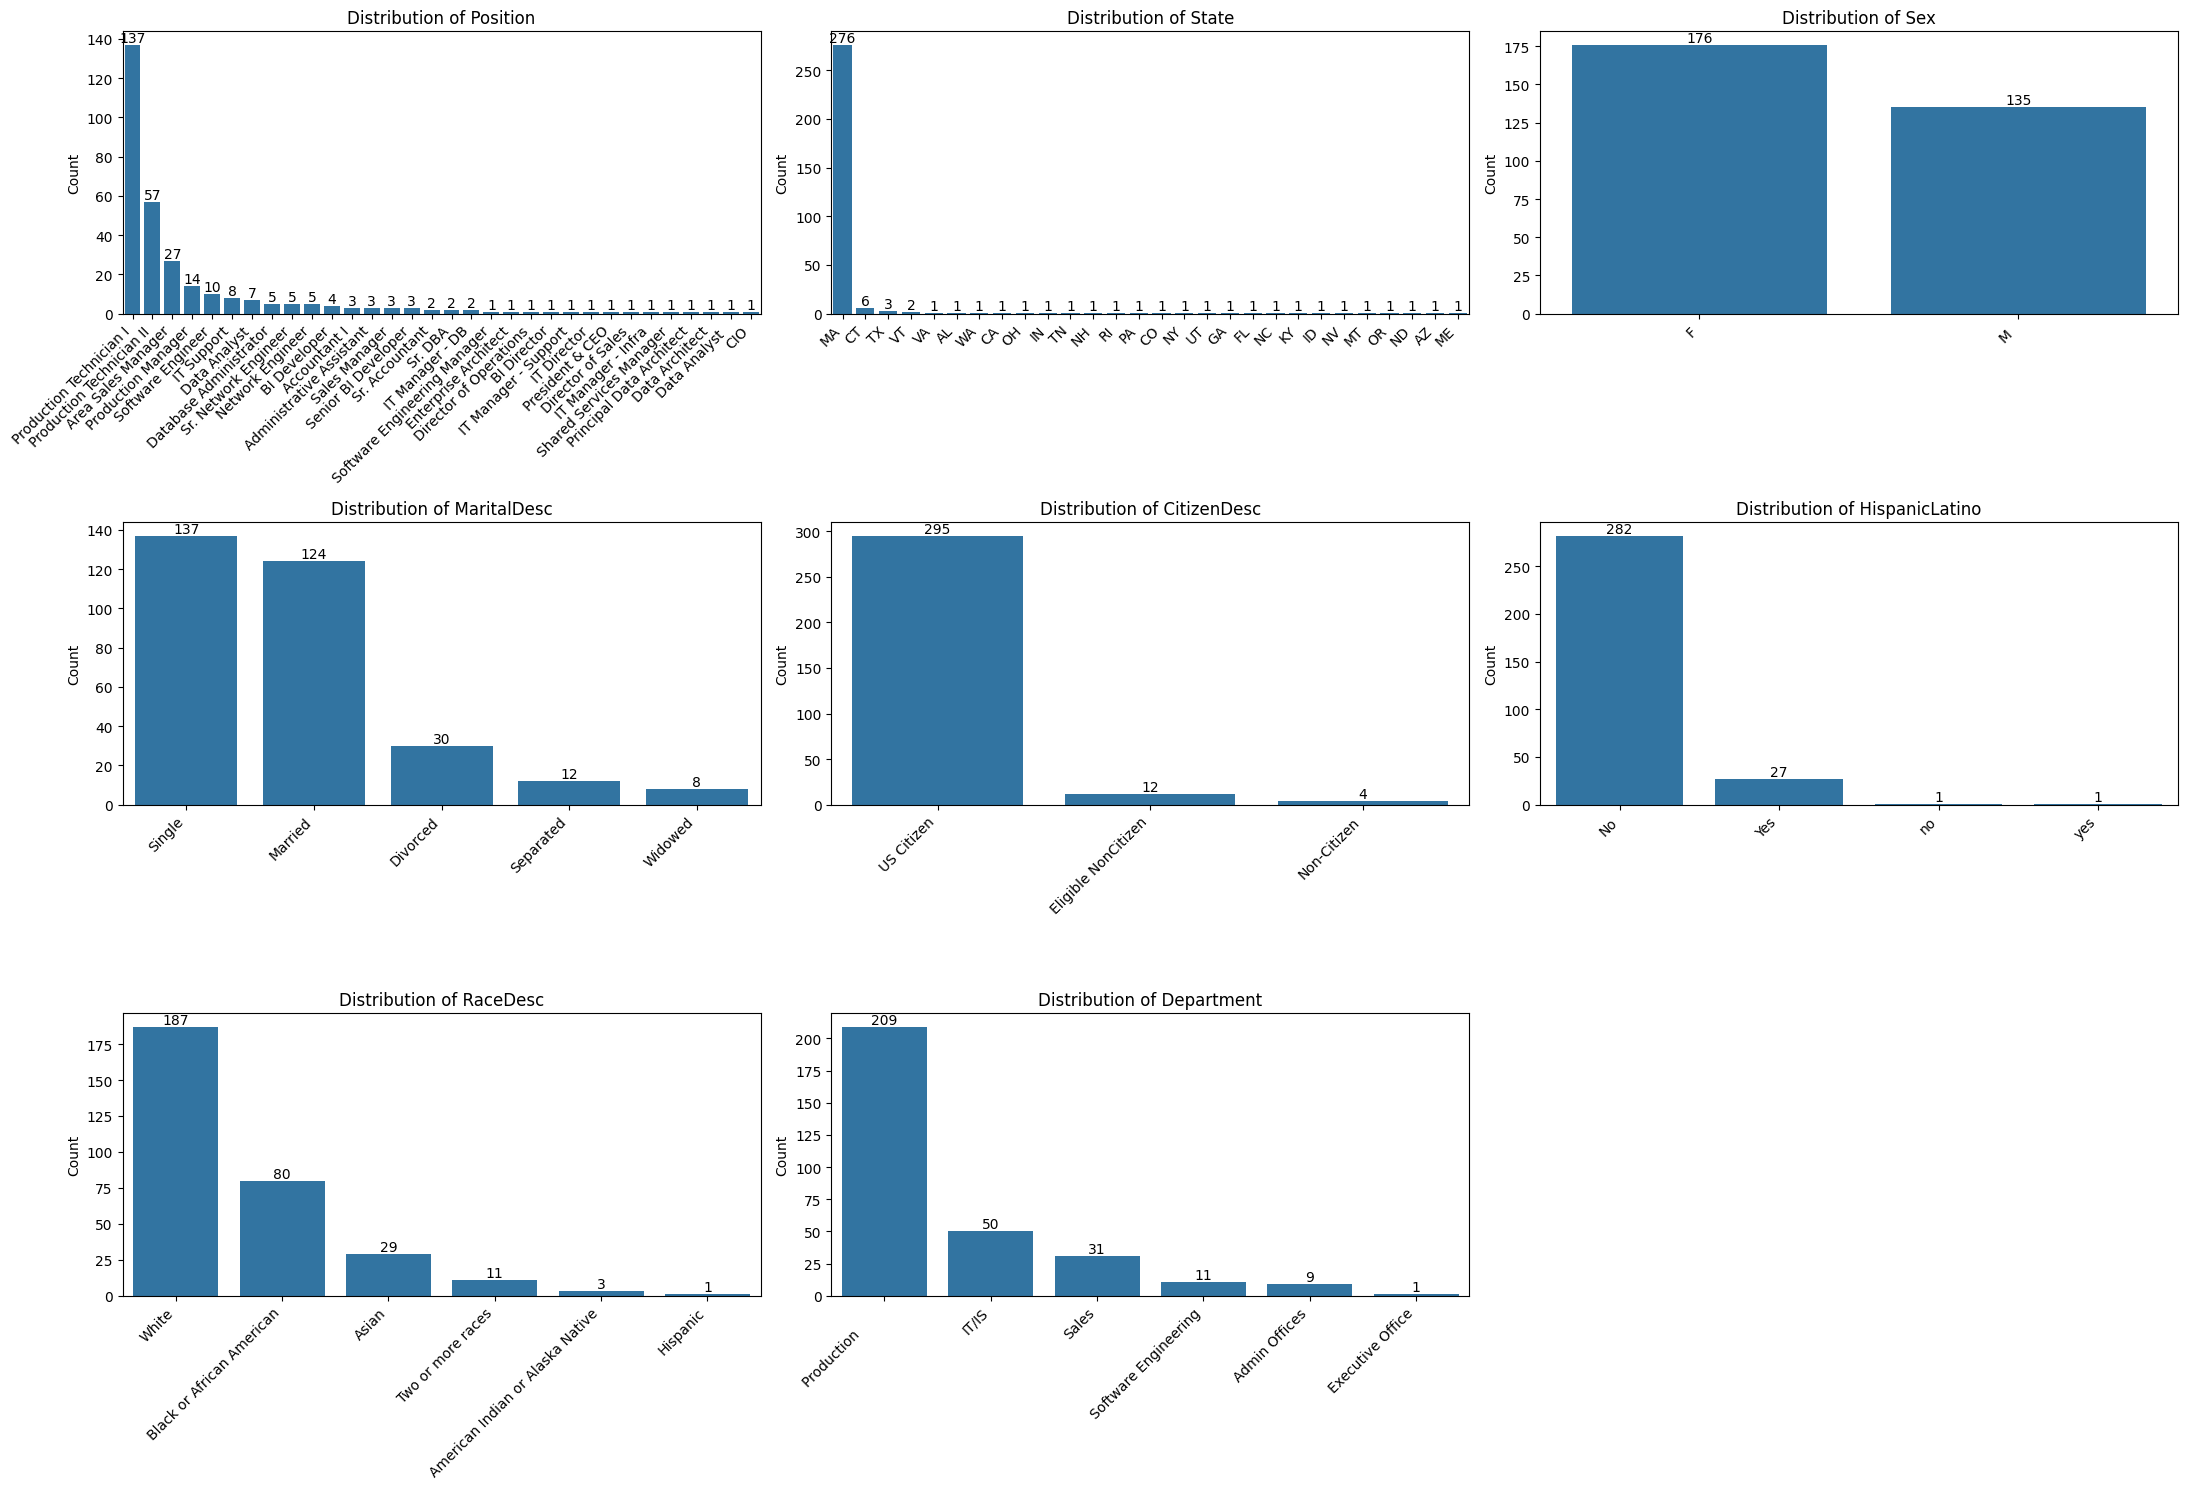

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def univariate_categorical(df, categorical_features):
    n_columns = 3
    n_rows = -(-len(categorical_features) // n_columns)

    plt.figure(figsize=(22, 5 * n_rows))

    for i, col in enumerate(categorical_features):
        plt.subplot(n_rows, n_columns, i + 1)

        ax = sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index
        )

        # Add value labels
        for container in ax.containers:
            ax.bar_label(container)

        plt.title(f'Distribution of {col}', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('')
        plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

univariate_categorical(df, categorical_cols)

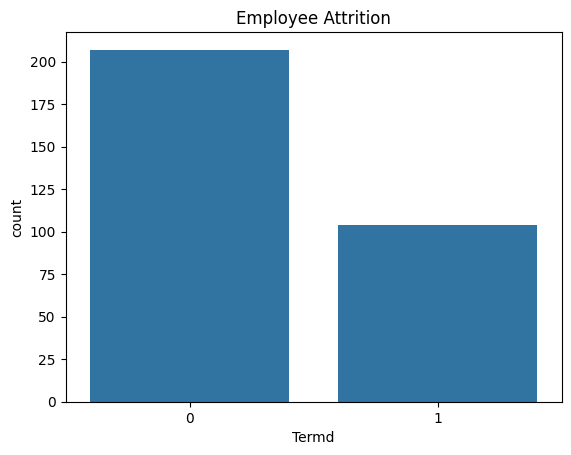

In [26]:
sns.countplot(data=df, x='Termd')
plt.title('Employee Attrition')
plt.show()

Univariate Numerical

In [27]:
numerical_cols = [
    'Salary',
    'EngagementSurvey',
    'EmpSatisfaction',
    'SpecialProjectsCount',
    'DaysLateLast30',
    'Absences',
    'Age',
    'TenureYears'
]

In [28]:
numerical_cols

['Salary',
 'EngagementSurvey',
 'EmpSatisfaction',
 'SpecialProjectsCount',
 'DaysLateLast30',
 'Absences',
 'Age',
 'TenureYears']

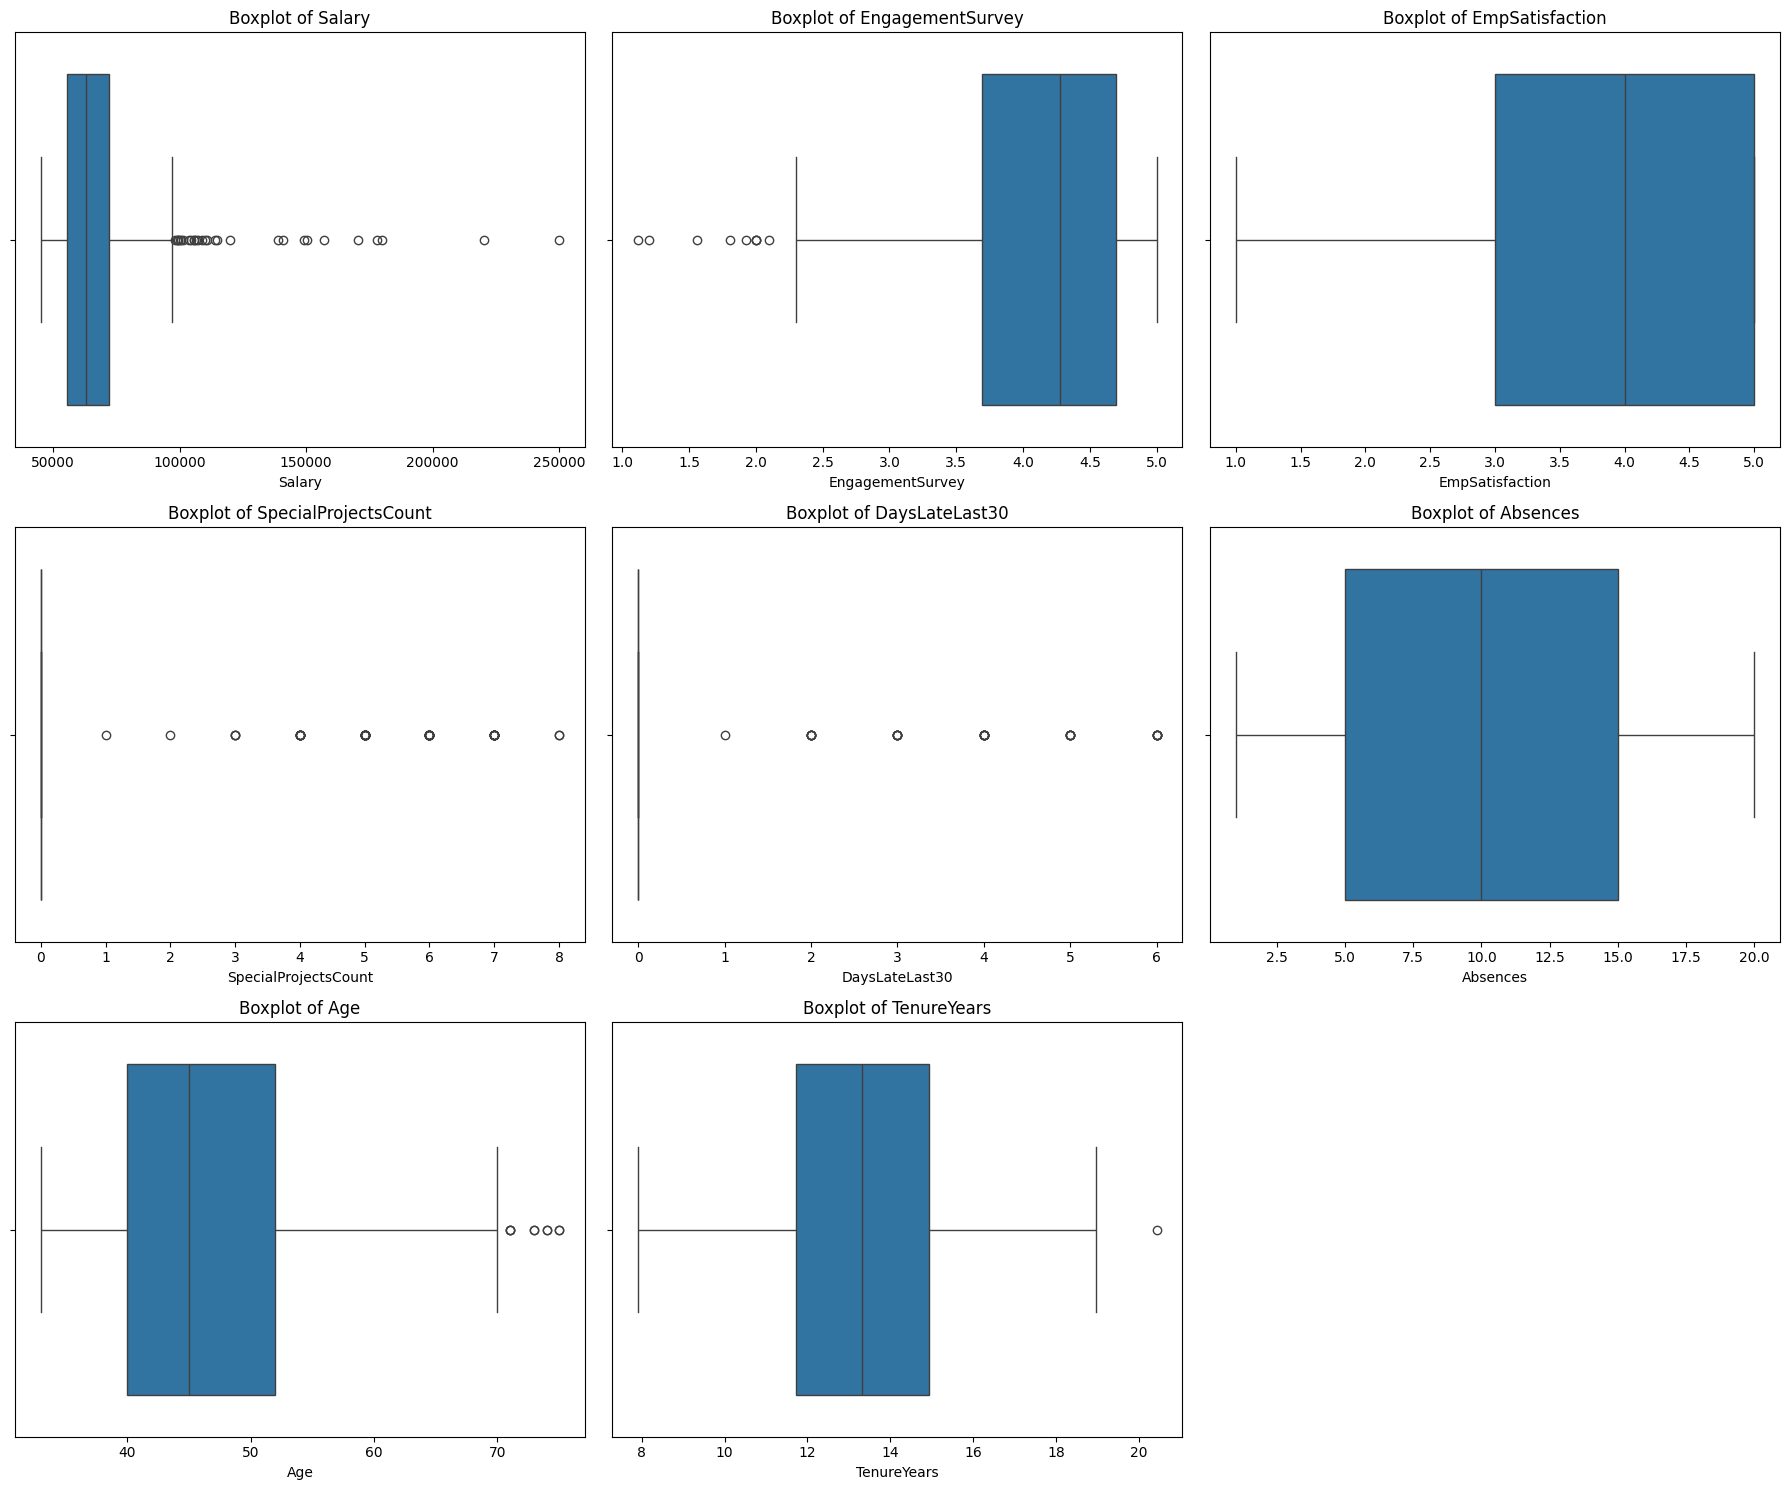

In [29]:
def univariate_numerical(df, numerical_features):
    n_columns = 3
    n_rows = -(-len(numerical_features) // n_columns)

    plt.figure(figsize=(18, 5 * n_rows))

    for i, col in enumerate(numerical_features):
        plt.subplot(n_rows, n_columns, i + 1)

        sns.boxplot(data=df, x=col)

        plt.title(f'Boxplot of {col}')
        plt.xlabel(col)

    plt.tight_layout()
    plt.show()

univariate_numerical(df, numerical_cols)

Hypotesis Testing

In [30]:
from scipy.stats import f_oneway

for col in numerical_cols:
    group0 = df[df['Termd'] == 0][col]
    group1 = df[df['Termd'] == 1][col]

    stat, p = f_oneway(group0, group1)

    print(f"{col}: p-value = {p:.4f}")

Salary: p-value = 0.0980
EngagementSurvey: p-value = 0.7580
EmpSatisfaction: p-value = 0.9338
SpecialProjectsCount: p-value = 0.0092
DaysLateLast30: p-value = 0.0161
Absences: p-value = 0.0836
Age: p-value = 0.0789
TenureYears: p-value = 0.0000


In [31]:
from scipy.stats import chi2_contingency

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Termd'])

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print(f"{col}: p-value = {p:.4f}")

Position: p-value = 0.1619
State: p-value = 0.7368
Sex: p-value = 0.8758
MaritalDesc: p-value = 0.0073
CitizenDesc: p-value = 0.1673
HispanicLatino: p-value = 0.7982
RaceDesc: p-value = 0.7671
Department: p-value = 0.0236


Handling Outliers

In [32]:
outlier_cols = [
    'Salary',
    'EngagementSurvey',
    'Absences',
    'Age',
    'TenureYears'
]

df_eda = df.copy()

for col in outlier_cols:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_eda = df_eda[
        (df_eda[col] >= lower_limit) &
        (df_eda[col] <= upper_limit)
    ]

df_prep = df_eda.reset_index(drop=True)


print(f"Outliers : {len(df_prep)}")


Outliers : 265


Modelling

In [33]:
TARGET_CATEGORICAL = 'Termd'

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X = df_prep.drop(columns=TARGET_CATEGORICAL)
y = df_prep[TARGET_CATEGORICAL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Feature Engineering


In [36]:
# Feature Engineering
# Age dibuat dari DOB
# TenureYears dibuat dari DateofHire

Encoding and Scaling

In [37]:
from sklearn.preprocessing import OrdinalEncoder

In [38]:
categorical_cols = [
    'Position',
    'State',
    'Sex',
    'MaritalDesc',
    'CitizenDesc',
    'HispanicLatino',
    'RaceDesc',
    'Department'
]


In [39]:


encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[categorical_cols] = encoder.fit_transform(
    X_train[categorical_cols]
)

X_test[categorical_cols] = encoder.transform(
    X_test[categorical_cols]
)

Scaling

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

Feature Selection

In [41]:
X_train = X_train.drop(columns=['EmploymentStatus'], errors='ignore')
X_test = X_test.drop(columns=['EmploymentStatus'], errors='ignore')

In [42]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = X_train.select_dtypes(include='object').columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [43]:
print(X_train.select_dtypes(include='object').columns.tolist())

[]


In [45]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

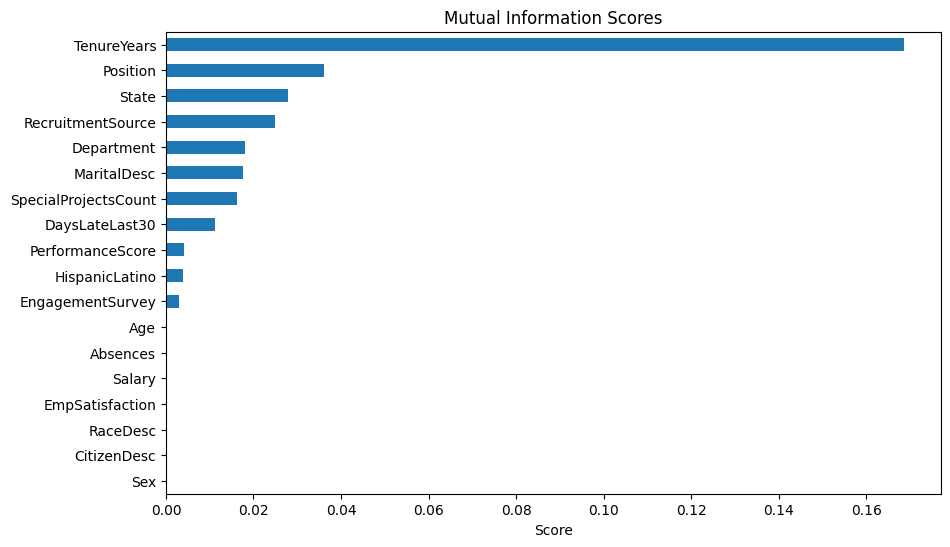

In [72]:
plt.figure(figsize=(10,6))

mi_scores.sort_values().plot(kind='barh')

plt.title('Mutual Information Scores')
plt.xlabel('Score')

plt.show()

In [46]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X_train.columns
).sort_values(ascending=False)

print(mi_scores)

TenureYears             0.168663
Position                0.036053
State                   0.027794
RecruitmentSource       0.024829
Department              0.018068
MaritalDesc             0.017596
SpecialProjectsCount    0.016294
DaysLateLast30          0.011158
PerformanceScore        0.004006
HispanicLatino          0.003920
EngagementSurvey        0.002933
Salary                  0.000000
Sex                     0.000000
CitizenDesc             0.000000
RaceDesc                0.000000
EmpSatisfaction         0.000000
Absences                0.000000
Age                     0.000000
dtype: float64


Feature Selection Based on Mi-Score

In [47]:
selected_features = mi_scores[mi_scores > 0.01].index.tolist()

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print(selected_features)

['TenureYears', 'Position', 'State', 'RecruitmentSource', 'Department', 'MaritalDesc', 'SpecialProjectsCount', 'DaysLateLast30']


Modelling

In [65]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_selected, y_train)

y_pred = lr.predict(X_test_selected)

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91        36
           1       0.86      0.71      0.77        17

    accuracy                           0.87        53
   macro avg       0.86      0.83      0.84        53
weighted avg       0.87      0.87      0.86        53



In [73]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

,0
TenureYears,0.315338
Salary,0.093827
EngagementSurvey,0.087566
Age,0.074020
Absences,0.065660
RecruitmentSource,0.064640
MaritalDesc,0.056530
Position,0.038815
EmpSatisfaction,0.032504
RaceDesc,0.031988


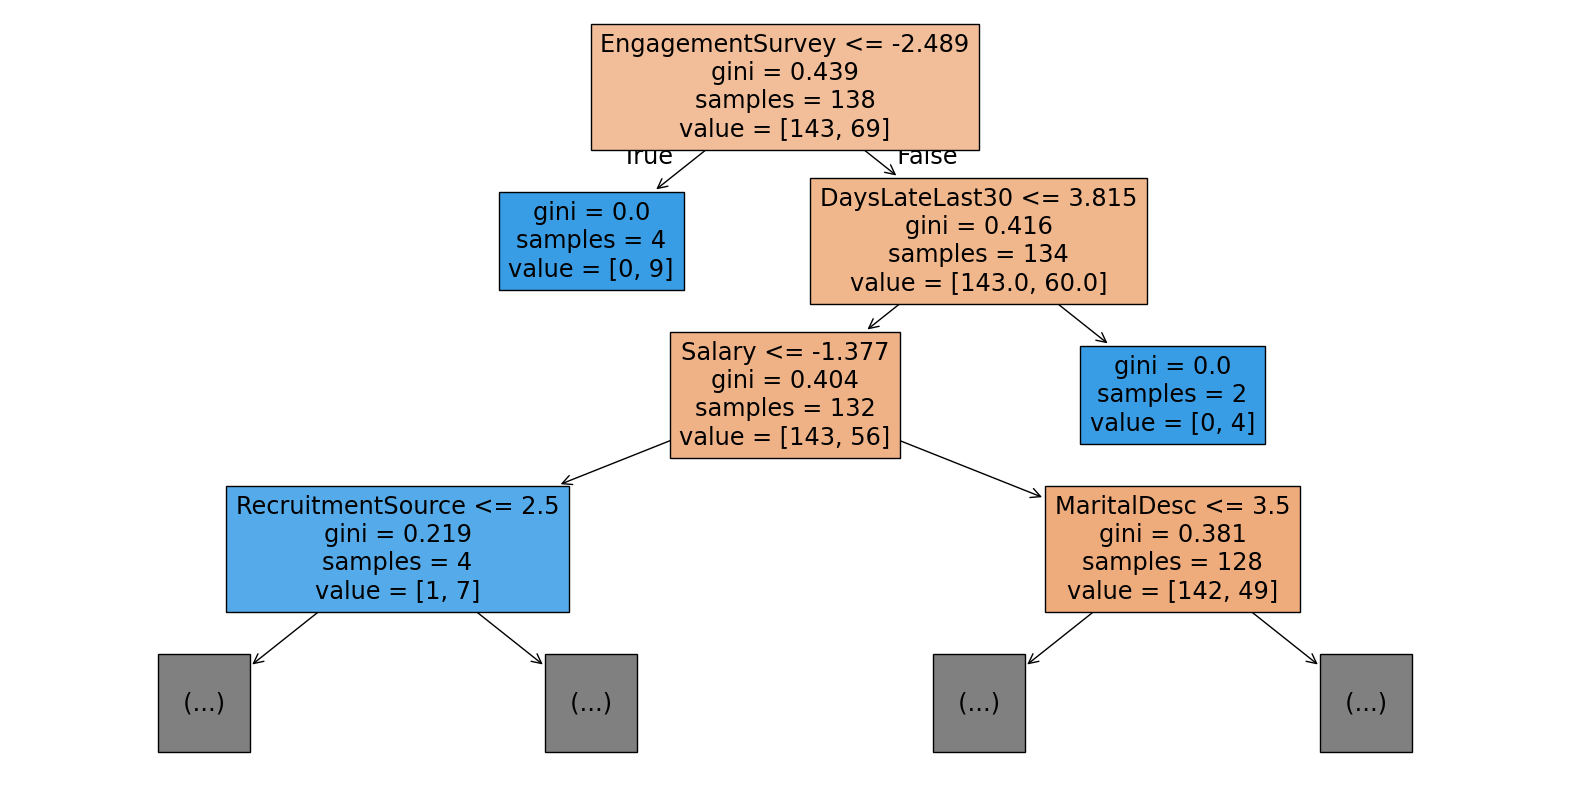

In [57]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    rf.estimators_[0],
    max_depth=3,
    feature_names=X_train.columns,
    filled=True
)

plt.show()

In [59]:
import pandas as pd

# Predict on test data
y_pred = rf.predict(X_test)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Display first 20 rows
print(comparison.head(20))

     Actual  Predicted
151       0          0
95        1          1
65        0          0
139       0          0
77        0          0
186       0          0
261       0          0
251       0          0
179       1          0
120       0          0
123       0          0
128       1          0
192       1          0
185       0          0
169       0          0
129       0          0
235       0          0
245       0          0
196       1          1
67        0          0


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Model Evaluation

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [76]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91        36
           1       0.86      0.71      0.77        17

    accuracy                           0.87        53
   macro avg       0.86      0.83      0.84        53
weighted avg       0.87      0.87      0.86        53



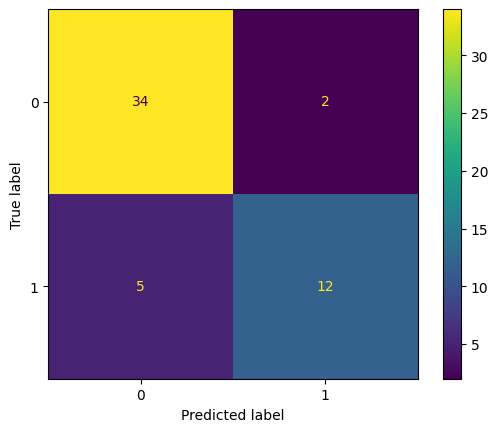

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.show()

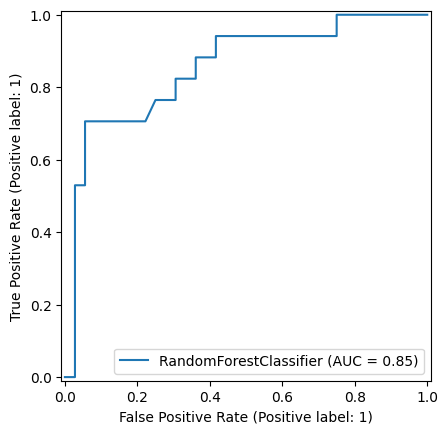

In [70]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()